# Sweep Analytics — Latent JacobianODE

Post-training diagnostics and model selection for a JacobianODE hyperparameter sweep.

**Inputs:** W&B project (and optional group) containing completed sweep runs.

**Workflow:**
1. Collect W&B runs and apply physics-informed model selection (C1/C2/C3)
2. Visualize selection criteria
3. Load the best model
4. Run diagnostics: reconstruction quality, prediction quality, Lyapunov exponents,
   latent space analysis, smoothness, Jacobian diagnostics, FNN loss, and more.

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import math
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import pandas as pd
import torch
from torch.autograd.functional import jacobian as autograd_jacobian
from torch.utils.data import RandomSampler, DataLoader
from tqdm.auto import tqdm
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    load_run,
    load_checkpoint,
    select_best_model,
    DiagnosticMetrics,
)
from JacobianODE.jacobians.metrics import r2_score, normalized_mse as nmse_fn, mase
from JacobianODE.jacobians.tuning import select_from_wandb_runs
from JacobianODE.jacobians.lightning_base import loop_closure
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.fnn import loss_false, loss_amplification

torch.set_float32_matmul_precision('high')

## 1. Settings

Specify the W&B project, optional group, and save directory for checkpoints.

In [ ]:
# ================================================================
# W&B project and group (EDIT THESE)
# ================================================================
WANDB_ENTITY  = "JacobianODE"
# WANDB_PROJECT = "Lorenz_IND012_N1_D1_NormTrue_L3__JacobianODE"  # <-- CHANGE THIS
# WANDB_GROUP   = "MLP_lc_sweep_enc_warmup_5"  # Set to a string to filter by group, or None for all runs

# WANDB_PROJECT = "Lorenz_IND012_N1_D1_NormTrue_L6__JacobianODE"
# WANDB_GROUP   = "sweep_from_scratch_lc_only_enc_warmup_5"
# WANDB_GROUP   = "sweep_from_scratch_lc_only_fnn1e-5_enc_warmup_5"

# WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_L3__JacobianODE"
# WANDB_GROUP   = "sweep_from_scratch_lc_only_fnn0_enc_warmup_5"

# WANDB_PROJECT   = "WMTask_INDall_N1_D1_NormTrue_L7__JacobianODE"
# WANDB_GROUP     = "sweep_from_scratch_lc_only_fnn0_enc_warmup_5"

# WANDB_PROJECT   = "Lorenz_IND0_N100_D1_NormTrue_L5__JacobianODE"
# WANDB_GROUP     = "sweep_from_scratch_lc_only_fnn0_enc_warmup_5"

# WANDB_PROJECT   = "Lorenz_IND0_N4_D11_NormTrue_L3__JacobianODE"
# WANDB_GROUP     = "sweep_from_scratch_lc_only_fnn0_enc_warmup_5"

# WANDB_PROJECT   = "Lorenz_IND0_N25_D1_NormTrue_L3__JacobianODE"
# WANDB_GROUP     = "sweep_from_scratch_lc_only_fnn0_enc_warmup_5_recent_True"

# WANDB_PROJECT   = "Lorenz_IND0_N25_D1_NormTrue_L3__JacobianODE"
# WANDB_GROUP     = "sweep_from_scratch_lc_only_fnn0_enc_warmup_0_recent_True"

# WANDB_PROJECT   = "Lorenz_IND012_N1_D1_NormTrue_T3__Coupling__JacobianODE"
# WANDB_GROUP     = "sweep_from_scratch_Coupling_lc+zp1.0_enc_warmup_5"

# WANDB_PROJECT   = "Lorenz_IND012_N2_D1_NormTrue_T3__Coupling__JacobianODE"
# WANDB_GROUP     = "sweep_from_scratch_Coupling_lc+zp1.0_enc_warmup_5"

# WANDB_PROJECT = "Lorenz_IND012_N2_D1_NormTrue_T6__Coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_Coupling_lc+zp1.0_enc_warmup_5"

# WANDB_PROJECT = "Lorenz_IND012_N2_D1_NormTrue_T6__Coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_Coupling_lc_9vals__zp1.0__tenc0.0_enc_warmup_5"

# # bad initialization
# WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_T3__Coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_coupling_lc_9vals__zp1.0__tenc0.0_enc_warmup_5"

# # better initialization
# WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_T3__coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5"

# # no Z-null penalty
# WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_T3__coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_coupling_lc_9vals__zp0.0__te0.0_enc_warmup_5"

# # no Z-null penalty, full obs
# WANDB_PROJECT = "Lorenz_IND012_N2_D1_NormTrue_T3__coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_coupling_lc_9vals__zp0.0__te0.0_enc_warmup_5"

# # more stable training, 2 epoch stopping
# WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_T3__coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab"

# spline coupling w/ full obs (N2)
WANDB_PROJECT = "Lorenz_IND012_N2_D1_NormTrue_T3__spline_coupling__JacobianODE"
WANDB_GROUP = "sweep_from_scratch_spline_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab"

# # spline coupling w/ partial obs (N25)
# WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_T3__spline_coupling__JacobianODE"
# WANDB_GROUP = "sweep_from_scratch_spline_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab"

WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# ================================================================
# Checkpoint save directory
# ================================================================
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"

# ================================================================
# Known true Lyapunov exponents (for Lorenz: sigma=10, rho=28, beta=8/3)
# Set to None for wmtask — will be overridden after loading first run (Section 3)
# ================================================================
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]  # None for wmtask (overridden from config)

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"W&B group:   {WANDB_GROUP}")
print(f"Save dir:    {SAVE_DIR}")

W&B project: JacobianODE/Lorenz_IND012_N2_D1_NormTrue_T3__spline_coupling__JacobianODE
W&B group:   sweep_from_scratch_spline_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab
Save dir:    /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs


## 2. Collect W&B Runs

In [6]:
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    all_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project: {e}")
    all_runs = []

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Found 9 total runs in JacobianODE/Lorenz_IND012_N2_D1_NormTrue_T3__spline_coupling__JacobianODE (group=sweep_from_scratch_spline_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab)


In [7]:
def _is_jac_ode_run(run):
    """Return True if this run has an encoder (i.e. is a JacobianODE run)."""
    return 'model' in run.config and 'encoder' in run.config.get('model', {})


def _get_loop_closure_weight(run):
    """Robustly extract loop_closure_weight from W&B run config (handles nested and flat formats)."""
    # Nested: config["training"]["lightning"]["loop_closure_weight"]
    try:
        val = run.config.get('training', {}).get('lightning', {}).get('loop_closure_weight')
        if val is not None:
            return float(val)
    except (TypeError, AttributeError):
        pass
    # Flat keys (W&B may use different separators)
    for key in ("training.lightning.loop_closure_weight", "training/lightning/loop_closure_weight"):
        if hasattr(run.config, 'get') and key in run.config:
            return float(run.config[key])
    return None


def _get_tangent_entropy_weight(run):
    """Robustly extract tangent_entropy_weight from W&B run config."""
    try:
        val = run.config.get('training', {}).get('lightning', {}).get('tangent_entropy_weight')
        if val is not None:
            return float(val)
    except (TypeError, AttributeError):
        pass
    for key in ("training.lightning.tangent_entropy_weight", "training/lightning/tangent_entropy_weight"):
        if hasattr(run.config, 'get') and key in run.config:
            return float(run.config[key])
    return 0.0


# Set to True to delete crashed runs from W&B (default False — keeps them for debugging, e.g. lc=0)
DELETE_CRASHED_RUNS = False

# Diagnostic: list all runs (helps debug why lc=0 may not show — e.g. crashed runs were being deleted)
print("All runs (state, loop_closure_weight, tangent_entropy_weight):")
for r in all_runs:
    lc = _get_loop_closure_weight(r)
    te = _get_tangent_entropy_weight(r)
    lc_str = str(lc) if lc is not None else "?"
    print(f"  {r.id}: state={r.state}, lc={lc_str}, te={te}")
print()

crashed_ids = []
for run in all_runs:
    if run.state in ('crashed', 'failed') and _is_jac_ode_run(run):
        lam = _get_loop_closure_weight(run)
        if DELETE_CRASHED_RUNS:
            print(f"CRASHED: run_id={run.id} (loop_closure_weight={lam}) — deleting from W&B")
            run.delete()
            crashed_ids.append(run.id)
        else:
            print(f"CRASHED: run_id={run.id} (loop_closure_weight={lam}) — keeping for debugging (set DELETE_CRASHED_RUNS=True to delete)")

if crashed_ids:
    print(f"\nDeleted {len(crashed_ids)} crashed run(s). Re-query if needed.")
elif any(r.state in ('crashed', 'failed') and _is_jac_ode_run(r) for r in all_runs):
    print("\nCrashed runs kept (DELETE_CRASHED_RUNS=False). Check run logs for debugging.")
else:
    print("No crashed JacobianODE runs found.")

All runs (state, loop_closure_weight, tangent_entropy_weight):
  0x1to4su: state=finished, lc=1e-05, te=0.0
  dhirg7kx: state=finished, lc=0.1, te=0.0
  ebq1plbn: state=finished, lc=0.0, te=0.0
  jkukakq3: state=finished, lc=1e-06, te=0.0
  ubzupy89: state=finished, lc=10.0, te=0.0
  5nwyyb64: state=finished, lc=0.01, te=0.0
  plj6l4cp: state=finished, lc=0.001, te=0.0
  8xu2t0il: state=finished, lc=0.0001, te=0.0
  52z4ns9t: state=finished, lc=1.0, te=0.0

No crashed JacobianODE runs found.


In [8]:
# ----------------------------------------------------------------
# Build sorted list of finished sweep runs
# ----------------------------------------------------------------
sweep_run_ids = []
sweep_lambdas = []
sweep_te_weights = []

for run in all_runs:
    if run.state != 'finished' or not _is_jac_ode_run(run):
        continue
    if run.id in crashed_ids:
        continue
    lc_weight = _get_loop_closure_weight(run)
    te_weight = _get_tangent_entropy_weight(run)
    if lc_weight is not None:
        sweep_run_ids.append(run.id)
        sweep_lambdas.append(lc_weight)
        sweep_te_weights.append(te_weight)

# Sort by lambda value
sorted_pairs = sorted(zip(sweep_lambdas, sweep_te_weights, sweep_run_ids))
sweep_lambdas = [p[0] for p in sorted_pairs]
sweep_te_weights = [p[1] for p in sorted_pairs]
sweep_run_ids = [p[2] for p in sorted_pairs]

print(f"\nFound {len(sweep_run_ids)} finished sweep runs:")
for lam, te, rid in zip(sweep_lambdas, sweep_te_weights, sweep_run_ids):
    print(f"  loop_closure_weight={lam}, tangent_entropy_weight={te} -> run_id={rid}")


Found 9 finished sweep runs:
  loop_closure_weight=0.0, tangent_entropy_weight=0.0 -> run_id=ebq1plbn
  loop_closure_weight=1e-06, tangent_entropy_weight=0.0 -> run_id=jkukakq3
  loop_closure_weight=1e-05, tangent_entropy_weight=0.0 -> run_id=0x1to4su
  loop_closure_weight=0.0001, tangent_entropy_weight=0.0 -> run_id=8xu2t0il
  loop_closure_weight=0.001, tangent_entropy_weight=0.0 -> run_id=plj6l4cp
  loop_closure_weight=0.01, tangent_entropy_weight=0.0 -> run_id=5nwyyb64
  loop_closure_weight=0.1, tangent_entropy_weight=0.0 -> run_id=dhirg7kx
  loop_closure_weight=1.0, tangent_entropy_weight=0.0 -> run_id=52z4ns9t
  loop_closure_weight=10.0, tangent_entropy_weight=0.0 -> run_id=ubzupy89


## 3. Compute Diagnostics and Select Best Model

Uses the tuning module's `select_from_wandb_runs` for physics-informed selection:

- **C1 (one-step MASE)**: model must beat persistence baseline (MASE < 1)
- **C2 (loop closure)**: loop closure loss must be below `sqrt(n_latent)`
- **C3 (eigenvalue)**: fraction of fast eigenvalues must be below threshold

In [9]:
# Load one run to determine data dimensionality and encoder latent dim
_run0, _cfg0, _eq0, _dt0, _values0, _, _, _, _, _ = load_run(
    WANDB_PROJECT_PATH,
    run_id=sweep_run_ids[0],
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=False,
)
n_dims = _values0.shape[-1]
n_latent = OmegaConf.select(_cfg0, "model.encoder.n_latent", default=None)
if n_latent is None:
    n_latent = n_dims  # fallback for non-latent models
dt = _dt0

# For coupling encoders, the dynamical system lives in z_dyn (first n_target_dims dims)
_n_target_dims = OmegaConf.select(_cfg0, "model.n_target_dims", default=None)
n_dyn = _n_target_dims if _n_target_dims is not None else n_latent

# Infer data source: dysts has eq (flow); wmtask has eq=None
DATA_SOURCE = OmegaConf.select(_cfg0, "data.data_type", default="dysts")
if DATA_SOURCE != "dysts":
    TRUE_LYAPUNOV = None  # wmtask has no known true Lyapunov exponents

print(f"n_dims = {n_dims}, n_latent = {n_latent}, n_dyn = {n_dyn}, dt = {dt:.4f}, data = {DATA_SOURCE}")
print(f"C2 loop-closure threshold: sqrt(n_dyn) = {np.sqrt(n_dyn):.4f}")

n_dims = 3, n_latent = 3, n_dyn = 3, dt = 0.0150, data = dysts
C2 loop-closure threshold: sqrt(n_dyn) = 1.7321


In [10]:
# ----------------------------------------------------------------
# Detect encoder type from model config
# ----------------------------------------------------------------
# For coupling encoders, n_target_dims is set in the model config.
# For standard encoders (MLP, SSM, etc.), n_target_dims is None.
import torch.nn.functional as F

n_target_dims = OmegaConf.select(_cfg0, "model.n_target_dims", default=None)
IS_COUPLING = n_target_dims is not None
N_DYN = n_target_dims if IS_COUPLING else n_latent

if IS_COUPLING:
    print(f"Coupling encoder detected: n_target_dims={n_target_dims}, full n_latent={n_latent}")
else:
    print(f"Standard encoder: n_latent={n_latent}")

def get_z_dyn(z):
    """Extract dynamic subspace from full latent encoding.

    No-op for standard (MLP/SSM/Transformer/TCN) encoders.
    For coupling encoders, returns z[..., :n_target_dims].
    """
    if n_target_dims is not None:
        return z[..., :n_target_dims]
    return z

def get_z_null(z):
    """Extract null subspace (penalized toward zero).

    Returns None for standard encoders.
    """
    if n_target_dims is not None:
        return z[..., n_target_dims:]
    return None

Coupling encoder detected: n_target_dims=3, full n_latent=3


In [11]:
sweep_result = select_from_wandb_runs(
    run_ids=sweep_run_ids,
    project=WANDB_PROJECT_PATH,
    dt=dt,
    n_dims=n_dims,
    n_batches=100,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
    lambda_values=sweep_lambdas,
    save_dir=SAVE_DIR,
    verbose=True,
    n_latent=n_latent,
)

result = sweep_result.selection
all_diagnostics = sweep_result.diagnostics

print("\n" + "=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda loop closure:    {sweep_lambdas[result.best_index]}")
print(f"Best lambda tangent entropy: {sweep_te_weights[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied: {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")

Loading run ebq1plbn (1/9)
Loading checkpoint epoch=12-step=2600.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/diagnostics_cache/ebq1plbn_n100.json
  run=ebq1plbn: DiagnosticMetrics(one_step_mase=0.40350616256823424, loop_closure_loss=9.689323878288269, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.012572824901435525)
Loading run jkukakq3 (2/9)
Loading checkpoint epoch=17-step=3600.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/diagnostics_cache/jkukakq3_n100.json
  run=jkukakq3: DiagnosticMetrics(one_step_mase=0.38541744446463727, loop_closure_loss=6.680333884954453, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.01243819655617699)
Loading run 0x1to4su (3/9)
Loading checkpoint epoch=12-step=2600.ckpt...
  Computing diagnostics (100 batches)...


...

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/diagnostics_cache/dhirg7kx_n100.json
  run=dhirg7kx: DiagnosticMetrics(one_step_mase=0.38682324864975953, loop_closure_loss=0.0018533034168649466, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.008868630630895496)
Loading run 52z4ns9t (8/9)
Loading checkpoint epoch=13-step=2800.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/diagnostics_cache/52z4ns9t_n100.json
  run=52z4ns9t: DiagnosticMetrics(one_step_mase=0.6470044617054121, loop_closure_loss=0.0005951321900647599, fast_eigenvalue_fraction=0.0, trajectory_val_loss=1.1950741738080979)
Loading run ubzupy89 (9/9)
Loading checkpoint epoch=51-step=10400.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/diagnostics_cache/ubzupy89_n100.json
  run=ubzupy89: DiagnosticMetrics(one_step_mase=0.5186430862164182, loop_closure_loss=0.0003726631583413109, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.11665118852630257)

MODEL SELECTION RESULT
Best lambda loop closure:    0.1
Best lambda tangent entropy: 0.0
Best run ID:    dhirg7kx
Best traj loss: 0.008869

Criteria applied: ['C1', 'C2', 'C3']
Surviving models: 7 / 9


## 4. Visualize Selection

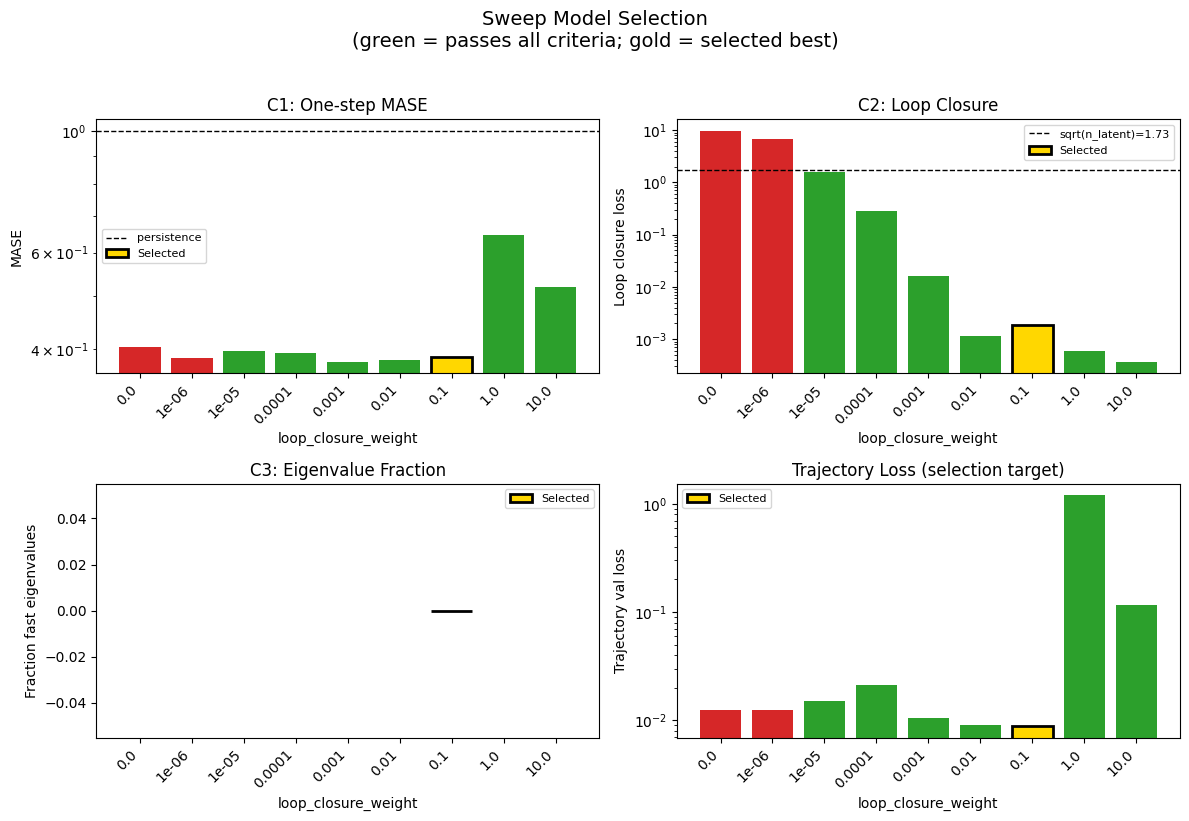

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

one_step_mases = [m.one_step_mase for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss for m in all_diagnostics]
eig_fracs = [m.fast_eigenvalue_fraction for m in all_diagnostics]
traj_losses = [m.trajectory_val_loss for m in all_diagnostics]

colors = ['tab:green' if i in result.surviving_indices else 'tab:red'
          for i in range(len(all_diagnostics))]
x_labels = [str(v) for v in sweep_lambdas]
x_pos = range(len(sweep_lambdas))

# Panel 1: One-step MASE
axes[0, 0].bar(x_pos, one_step_mases, color=colors)
if result.best_index is not None:
    axes[0, 0].bar(result.best_index, one_step_mases[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 0].axhline(y=1.0, color='k', linestyle='--', lw=1, label='persistence')
axes[0, 0].set_xticks(x_pos); axes[0, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 0].set_ylabel('MASE'); axes[0, 0].set_title('C1: One-step MASE')
axes[0, 0].set_yscale('log')
axes[0, 0].legend(fontsize=8)

# Panel 2: Loop closure loss
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
if result.best_index is not None:
    axes[0, 1].bar(result.best_index, loop_closure_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 1].axhline(y=np.sqrt(n_latent), color='k', linestyle='--', lw=1,
                   label=f'sqrt(n_latent)={np.sqrt(n_latent):.2f}')
axes[0, 1].set_xticks(x_pos); axes[0, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 1].set_ylabel('Loop closure loss'); axes[0, 1].set_title('C2: Loop Closure')
axes[0, 1].legend(fontsize=8); axes[0, 1].set_yscale('log')

# Panel 3: Fast eigenvalue fraction
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
if result.best_index is not None:
    axes[1, 0].bar(result.best_index, eig_fracs[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 0].set_ylabel('Fraction fast eigenvalues'); axes[1, 0].set_title('C3: Eigenvalue Fraction')
axes[1, 0].legend(fontsize=8)

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 1].set_ylabel('Trajectory val loss'); axes[1, 1].set_title('Trajectory Loss (selection target)')
axes[1, 1].legend(fontsize=8); axes[1, 1].set_yscale('log')

for ax in axes.flat:
    ax.set_xlabel('loop_closure_weight')

fig.suptitle(
    'Sweep Model Selection\n'
    '(green = passes all criteria; gold = selected best)',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## 5. Load the Best Model

Load the selected model's architecture, data, and checkpoint from W&B.

In [13]:
idx = result.best_index
# idx = 2  # Override to manually select a different model

best_run_id = sweep_run_ids[idx]
best_lambda = sweep_lambdas[idx]
print(f"Loading model: run_id={best_run_id}, loop_closure_weight={best_lambda}")

# Step 1: Load architecture + trajectory data
run, best_cfg, eq, dt, values, _, _, _, _, best_lit_model = load_run(
    WANDB_PROJECT_PATH,
    run_id=best_run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# Step 2: Build dataloaders
train_dl, val_dl, test_dl, trajs = create_dataloaders(
    best_cfg, values, verbose=True, return_full_obs=True
)
test_trajs_full = trajs['test_trajs_full'].sequence

# Step 3: Load checkpoint
load_checkpoint(run, best_cfg, best_lit_model, save_dir=SAVE_DIR, verbose=True)

# Step 4: Restore attributes (skip true_lyapunov_exponents for wmtask; no known ground truth)
if TRUE_LYAPUNOV is not None:
    best_lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
best_lit_model.eval()

# Extract useful config values
mu = best_cfg.data.postprocessing.mu
sigma = best_cfg.data.postprocessing.sigma
OBSERVED_INDICES = best_cfg.data.train_test_params.delay_embedding_params.observed_indices
N_DELAYS = best_cfg.data.train_test_params.delay_embedding_params.n_delays
DELAY_SPACING = best_cfg.data.train_test_params.delay_embedding_params.delay_spacing
PREDICTION_STEPS = best_lit_model.prediction_steps
n_dims = values.shape[-1]
n_obs = trajs['train_trajs'].sequence.shape[-1]

print(f"\nModel type: {type(best_lit_model).__name__}")
print(f"Total params: {sum(p.numel() for p in best_lit_model.parameters()):,}")
print(f"Test trajectories (full obs): {test_trajs_full.shape}")

Loading model: run_id=dhirg7kx, loop_closure_weight=0.1


Sequence Indices:   0%|          | 0/1154 [00:00<?, ?it/s]

Train dataset shape: torch.Size([25388, 45, 6])
Validation dataset shape: torch.Size([8078, 45, 6])
Test dataset shape: torch.Size([3462, 45, 6])
Train trajectories dataset shape: torch.Size([22, 1199, 6])
Validation trajectories dataset shape: torch.Size([7, 1199, 6])
Test trajectories dataset shape: torch.Size([3, 1199, 6])
Loading checkpoint epoch=54-step=11000.ckpt...

Model type: LitLatentJacobianODE
Total params: 6,791,873
Test trajectories (full obs): torch.Size([3, 1200, 3])


## 6. Reconstruction Quality

Encode-then-decode (no prediction) to check autoencoder quality.

Reconstruction nMSE: 0.000000
Inverse consistency MSE (encode→decode): 1.357606e-13
Null subspace RMS: 6.046310e-03
padding with 3 zeros


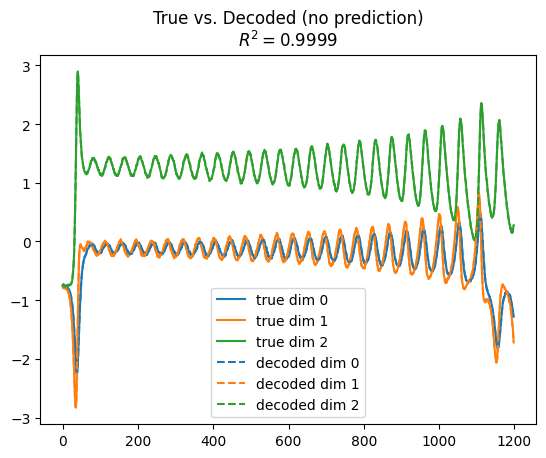

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = best_lit_model.to(device)
lit_model.eval()

# Determine decoder output dim (may be < n_input if decode_only_recent)
if hasattr(lit_model.encoder, 'decoder'):
    _decoder_n_out = lit_model.encoder.decoder.n_output
else:
    # Coupling encoder: inverse maps back to full observation dim (n_latent == n_input)
    _decoder_n_out = lit_model.encoder.n_latent

# Time offset: delay embedding drops (n_delays-1)*delay_spacing points from the start
_time_offset = (N_DELAYS - 1) * DELAY_SPACING

# Reconstruction on test data
with torch.no_grad():
    batch = test_dl.dataset.sequence[:16].to(device)
    z = lit_model.encode_trajectory(batch)
    recon = lit_model.decode_trajectory(z)
    margin = getattr(lit_model.encoder, 'context_margin', 0)
    targets = batch[:, margin:] if margin > 0 else batch
    targets = targets[..., :_decoder_n_out]
    recon_mse = ((recon - targets)**2).mean().item()
    recon_nmse = recon_mse / targets.var().item()
    print(f"Reconstruction nMSE: {recon_nmse:.6f}")
    if getattr(lit_model, 'decode_only_recent', False):
        print(f"  (decode_only_recent=True, decoder outputs {_decoder_n_out} of {batch.shape[-1]} dims)")

# Coupling-specific: inverse consistency and null subspace diagnostics
if IS_COUPLING:
    with torch.no_grad():
        z_check = lit_model.encode_trajectory(batch)
        x_roundtrip = lit_model.decode_trajectory(z_check)
        inv_err = F.mse_loss(x_roundtrip, batch).item()
        z_null = get_z_null(z_check)
        null_rms = z_null.pow(2).mean().sqrt().item() if z_null is not None and z_null.numel() > 0 else 0
        print(f"Inverse consistency MSE (encode→decode): {inv_err:.6e}")
        print(f"Null subspace RMS: {null_rms:.6e}")

# Plot: true vs decoded (first test trajectory)
test_trajs_obs = trajs['test_trajs'].sequence
with torch.no_grad():
    latent_traj_full = lit_model.encode_trajectory(test_trajs_obs.to(device))
    if IS_COUPLING:
        latent_traj_full = get_z_dyn(latent_traj_full)
        # pad
        if z_null is not None:
            print(f"padding with {z_null.shape[-1]} zeros")
        else:
            print("no null space, not padding")
        latent_traj_full = lit_model._pad_to_full_dim(latent_traj_full)
    traj_decoded_full = lit_model.decode_trajectory(latent_traj_full)

latent_traj_full = latent_traj_full.cpu()
traj_decoded_full = traj_decoded_full.cpu()

# Align true trajectory with decoded: delay embedding shifts by _time_offset
# test_trajs_full has the original (pre-delay-embedding) dims and full time length
test_trajs_full_aligned = test_trajs_full[:, _time_offset:]

# For decode_only_recent, decoder outputs n_raw_obs dims which match test_trajs_full's
# observed indices; for full decode, compare against delay-embedded obs
if getattr(lit_model, 'decode_only_recent', False):
    # Decoder outputs raw observed dims — compare against test_trajs_full (already n_raw_obs)
    if OBSERVED_INDICES != 'all':
        plot_targets = test_trajs_full_aligned[..., OBSERVED_INDICES]
    else:
        plot_targets = test_trajs_full_aligned
else:
    # Decoder outputs full delay embedding — compare against delay-embedded obs
    plot_targets = test_trajs_obs

if lit_model.reconstruction_mode == 'most_recent':
    plot_dims = np.arange(lit_model.n_recent_dims)
else:
    n_dims = min(10, plot_targets.shape[-1], traj_decoded_full.shape[-1])
    plot_dims = np.arange(n_dims)
T_plot = min(plot_targets.shape[1], traj_decoded_full.shape[1])
for i in plot_dims:
    plt.plot(plot_targets[0, :T_plot, i].numpy(), c=f"C{i}", label=f'true dim {i}')
for i in plot_dims:
    plt.plot(traj_decoded_full[0, :T_plot, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded dim {i}')
r2_val = r2_score(
    plot_targets[:, :T_plot, plot_dims].reshape(-1, len(plot_dims)),
    traj_decoded_full[:, :T_plot, plot_dims].reshape(-1, len(plot_dims)),
)
plt.title(f"True vs. Decoded (no prediction)\n$R^2 = {r2_val:.4f}$")
plt.legend()
plt.show()

## 7. Prediction Quality

Teacher-forced (one-step) and free-running predictions on validation data.

In [15]:
model_maes_forced = []
model_maes_free = []
persistence_maes = []

n_batches = 10
RAND_SEED = 42
generator = torch.Generator().manual_seed(RAND_SEED)
dl = val_dl
num_samples = n_batches * dl.batch_size
rand_sampler = RandomSampler(dl.dataset, num_samples=num_samples, replacement=False, generator=generator)
rand_dl = DataLoader(
    dl.dataset, batch_size=dl.batch_size, sampler=rand_sampler,
    num_workers=dl.num_workers, pin_memory=getattr(dl, 'pin_memory', False),
)

for i, batch in enumerate(tqdm(rand_dl, desc="Evaluating", total=n_batches)):
    if i >= n_batches:
        break
    batch = batch.to(device)
    with torch.no_grad():
        ret_forced = lit_model.trajectory_model_step(batch, alpha_teacher_forcing=1, return_decoded=True)
        ret_free = lit_model.trajectory_model_step(batch, alpha_teacher_forcing=0, return_decoded=True)
    model_maes_forced.append(ret_forced['metric_vals']['model_mae'].item())
    model_maes_free.append(ret_free['metric_vals']['model_mae'].item())
    persistence_maes.append(ret_free['metric_vals']['persistence_mae'].item())

forced_mase = torch.tensor(model_maes_forced).mean() / torch.tensor(persistence_maes).mean()
free_mase = torch.tensor(model_maes_free).mean() / torch.tensor(persistence_maes).mean()

print(f"Teacher-forced MASE: {forced_mase:.4f}")
print(f"Free-running MASE:   {free_mase:.4f}")
print(f"Mean persistence MAE: {torch.tensor(persistence_maes).mean():.6f}")

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Teacher-forced MASE: 0.3661
Free-running MASE:   0.7334
Mean persistence MAE: 0.035698


## 8. Latent Space Analysis — Utilization, PCA Embeddings

test_trajs_full.shape: torch.Size([3, 1200, 3])
latent_traj_full.shape: torch.Size([3, 1199, 6])


  0%|          | 0/3 [00:00<?, ?it/s]

Z shape: (22, 1199, 6), Z_dyn shape: (22, 1199, 3), X_true shape: (22, 1199, 3)


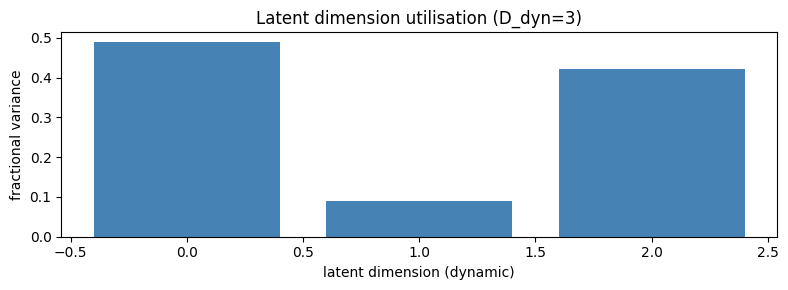

Entropy-based utilization: 0.847  (1.0 = uniform)


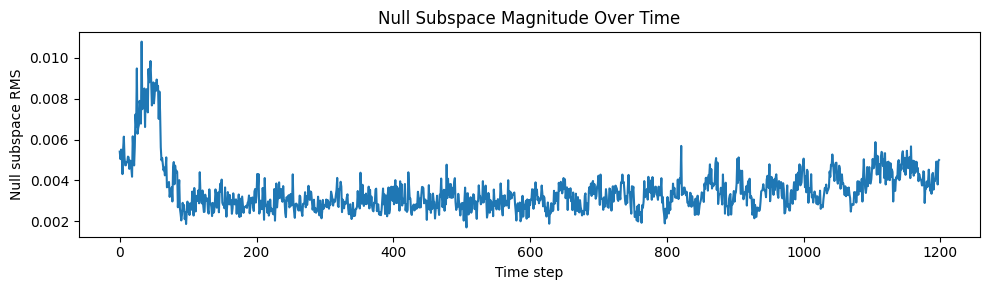

Null subspace mean RMS: 3.651677e-03


In [16]:
from sklearn.decomposition import PCA

def participation_ratio(X):
    X_flat = X.reshape(-1, X.shape[-1])
    cov = np.cov(X_flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    return (eigvals.sum())**2 / ((eigvals**2).sum() + 1e-12)
print(f"test_trajs_full.shape: {test_trajs_full.shape}")
print(f"latent_traj_full.shape: {latent_traj_full.shape}")
pr_true = participation_ratio(test_trajs_full)
pr_latent = participation_ratio(latent_traj_full)

# Encode full trajectories
use_train = True
traj_key = "train_trajs" if use_train else "test_trajs"
full_obs_key = "train_trajs_full" if use_train else "test_trajs_full"
label_prefix = "Train" if use_train else "Test"

trajs_obs = trajs[traj_key].sequence
trajs_full_arr = np.asarray(trajs[full_obs_key].sequence)

all_latents = []
with torch.no_grad():
    for i in tqdm(range(0, trajs_obs.shape[0], 8)):
        x = torch.as_tensor(trajs_obs[i:i+8]).float().to(device)
        z = lit_model.encode_trajectory(x)
        all_latents.append(z.cpu())
Z = torch.cat(all_latents, dim=0).numpy()

# Extract dynamic subspace for latent-space analysis
Z_dyn = get_z_dyn(torch.from_numpy(Z)).numpy()

T_latent = Z.shape[1]
X_true = trajs_full_arr[:, -T_latent:, :]
print(f"Z shape: {Z.shape}, Z_dyn shape: {Z_dyn.shape}, X_true shape: {X_true.shape}")

# Use Z_dyn for all latent-space analysis (PCA, utilization, etc.)
Z_flat = Z_dyn.reshape(-1, Z_dyn.shape[-1])
X_true_flat = X_true.reshape(-1, X_true.shape[-1])

# Per-dimension variance (latent utilization) — on dynamic subspace
dim_var = Z_flat.var(axis=0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(dim_var)), dim_var / dim_var.sum(), color='steelblue')
ax.set_xlabel('latent dimension (dynamic)'); ax.set_ylabel('fractional variance')
ax.set_title(f'Latent dimension utilisation (D_dyn={Z_dyn.shape[-1]})')
plt.tight_layout(); plt.show()

p = dim_var / dim_var.sum()
entropy = -np.sum(p * np.log(p + 1e-10))
n_dyn = Z_flat.shape[-1]
utilization = entropy / math.log(n_dyn) if n_dyn > 1 else 1.0
print(f'Entropy-based utilization: {utilization:.3f}  (1.0 = uniform)')

# Null subspace monitoring (coupling only)
if IS_COUPLING:
    Z_null = get_z_null(torch.from_numpy(Z)).numpy()
    null_rms_per_t = np.sqrt((Z_null ** 2).mean(axis=(0, 2)))
    plt.figure(figsize=(10, 3))
    plt.plot(null_rms_per_t)
    plt.xlabel("Time step"); plt.ylabel("Null subspace RMS")
    plt.title("Null Subspace Magnitude Over Time")
    plt.tight_layout(); plt.show()
    print(f"Null subspace mean RMS: {np.sqrt((Z_null ** 2).mean()):.6e}")

## 9. Lyapunov Exponent Comparison

In [17]:
def kaplan_yorke_dim(lyap_exps):
    """
    Compute the Kaplan-Yorke (Lyapunov) dimension D_KY given the Lyapunov exponents.
    D_KY = k + (sum_{i=1}^k lambda_i) / |lambda_{k+1}|,
    where k is the largest integer such that sum_{i=1}^k lambda_i > 0,
    and lambda_i are sorted in decreasing order.

    Handles batches of shape [B, N] and outputs [B].
    (Torch version)
    """
    lyap_exps = torch.as_tensor(lyap_exps)
    if lyap_exps.ndim == 1:
        lyap_exps = lyap_exps.unsqueeze(0)  # Shape [1, N]
    B, N = lyap_exps.shape
    lyap_sorted, _ = torch.sort(lyap_exps, descending=True, dim=1)  # Shape [B, N]
    cumsum = torch.cumsum(lyap_sorted, dim=1)  # Shape [B, N]

    # Find 'k' for each batch: largest integer s.t. sum_{i=1}^k lambda_i > 0
    mask_pos = cumsum > 0  # [B, N]
    k_idx = mask_pos.sum(dim=1) - 1  # [B]; -1 if no values > 0

    D_KY = torch.zeros(B, dtype=lyap_exps.dtype, device=lyap_exps.device)
    for b in range(B):
        k = k_idx[b].item()
        if k < 0:
            D_KY[b] = 0.0
            continue
        sum_k = cumsum[b, k]
        if (k + 1) < N and lyap_sorted[b, k+1] != 0:
            D_KY[b] = (k + 1) + sum_k / torch.abs(lyap_sorted[b, k+1])
        else:
            D_KY[b] = float(N)
    return D_KY if D_KY.shape[0] > 1 else D_KY[0]

lit_model.eval()
lit_model = lit_model.to(device)

N_SAMPLE = 128

with torch.no_grad():
    traj_full = torch.as_tensor(test_dl.dataset.sequence).float().to(device)
    n_test_trajs = traj_full.shape[0]
    T_full = traj_full.shape[1]
    print(f"Using {n_test_trajs} full-length test trajectories, T={T_full} each")

    z_full = lit_model.encode_trajectory(traj_full)
    # CRITICAL: compute_jacobians expects z_dyn for coupling models
    # (MLP has input_dim = n_target_dims, not full n_latent)
    z_for_jac = get_z_dyn(z_full)
    # random sample N_SAMPLE trajectories
    # seed a generator for reproducibility
    generator = torch.Generator().manual_seed(0)
    z_for_jac = z_for_jac[torch.randperm(z_for_jac.shape[0], generator=generator)[:N_SAMPLE]]
    jacs = lit_model.compute_jacobians(z_for_jac)
    all_pred_lyap = LitLatentJacobianODE.compute_lyapunov_exponents(jacs, dt)

    pred_lyap = all_pred_lyap.mean(dim=0)
    pred_lyap_std = all_pred_lyap.std(dim=0)

print(f"\nPredicted Lyapunov exponents (mean +/- std over {N_SAMPLE} trajs):")
for i, (le, std) in enumerate(zip(pred_lyap, pred_lyap_std)):
    print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")
print(f"\nTrue Lorenz: {TRUE_LYAPUNOV}")
print(f"Kaplan-Yorke dimension: {kaplan_yorke_dim(all_pred_lyap).mean():.3f} +/- {kaplan_yorke_dim(all_pred_lyap).std():.3f}")

Using 3462 full-length test trajectories, T=45 each

Predicted Lyapunov exponents (mean +/- std over 128 trajs):
  lambda_1 = +0.8994 +/- 0.5874
  lambda_2 = -0.5472 +/- 0.7111
  lambda_3 = -12.0368 +/- 1.6064

True Lorenz: [0.91, 0.0, -14.57]
Kaplan-Yorke dimension: 1.991 +/- 0.248


In [18]:
# Define the number of artificial burn-in steps to append
T_BURN = 400
T_DROP = 100

lit_model.eval()
lit_model = lit_model.to(device)

N_SAMPLE = 128

with torch.no_grad():
    traj_full = torch.as_tensor(test_dl.dataset.sequence).float().to(device)
    n_test_trajs = traj_full.shape[0]
    T_full = traj_full.shape[1]
    print(f"Using {n_test_trajs} full-length test trajectories, T={T_full} each")

    z_full = lit_model.encode_trajectory(traj_full)
    z_for_jac = get_z_dyn(z_full)
    
    # random sample N_SAMPLE trajectories
    generator = torch.Generator().manual_seed(0)
    z_for_jac = z_for_jac[torch.randperm(z_for_jac.shape[0], generator=generator)[:N_SAMPLE]]
    
    # --- 1. The Artificial Burn-In ---
    # Pad the true sequence with zeros so the ODE solver knows how many steps to simulate
    B, T_true, D_dyn = z_for_jac.shape
    z_padded = torch.cat([z_for_jac, torch.zeros(B, T_BURN, D_dyn, device=device)], dim=1)
    
    print(f"Running artificial burn-in for {T_BURN} steps...")
    from JacobianODE.jacobians.jacobianODE import JacobianODEint
    jacobian_odeint = JacobianODEint(lit_model.compute_jacobians, dt)
    
    # generate_dynamics uses the first `traj_init_steps` as history, 
    # and integrates forward to fill the remaining padded length.
    z_combined = jacobian_odeint.generate_dynamics(
        z_padded,
        traj_init_steps=T_true,
        alpha_teacher_forcing=0.0, 
        fast_mode=True,
        verbose=True,
        interp_pts=4,
        inner_N=20
    )
    
    print(f"Combined trajectory length: {z_combined.shape[1]} (True: {T_true}, Burn: {T_BURN}, Drop: {T_DROP}, Using: {T_true + T_BURN - T_DROP})")
    
    # --- 2. The Jacobian Calculation ---
    # Calculate Jacobians over the ENTIRE combined sequence (True + Burn-in)
    jacs = lit_model.compute_jacobians(z_combined)
    all_pred_lyap = LitLatentJacobianODE.compute_lyapunov_exponents(jacs[:, T_DROP:], dt)

    pred_lyap = all_pred_lyap.mean(dim=0)
    pred_lyap_std = all_pred_lyap.std(dim=0)

print(f"\nPredicted Lyapunov exponents (mean +/- std over {N_SAMPLE} trajs):")
for i, (le, std) in enumerate(zip(pred_lyap, pred_lyap_std)):
    print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")
print(f"\nTrue Lorenz: {TRUE_LYAPUNOV}")
print(f"Kaplan-Yorke dimension: {kaplan_yorke_dim(all_pred_lyap).mean():.3f} +/- {kaplan_yorke_dim(all_pred_lyap).std():.3f}")

Using 3462 full-length test trajectories, T=45 each
Running artificial burn-in for 400 steps...


  0%|          | 0/400 [00:00<?, ?it/s]

Combined trajectory length: 445 (True: 45, Burn: 400, Drop: 100, Using: 345)

Predicted Lyapunov exponents (mean +/- std over 128 trajs):
  lambda_1 = +0.5220 +/- 0.3176
  lambda_2 = -0.0125 +/- 0.1411
  lambda_3 = -11.7608 +/- 1.3102

True Lorenz: [0.91, 0.0, -14.57]
Kaplan-Yorke dimension: 2.046 +/- 0.028


In [19]:
lit_model.eval()
lit_model = lit_model.to(device)

with torch.no_grad():
    traj_full = torch.as_tensor(trajs['test_trajs'].sequence).float().to(device)
    n_test_trajs = traj_full.shape[0]
    T_full = traj_full.shape[1]
    print(f"Using {n_test_trajs} full-length test trajectories, T={T_full} each")

    z_full = lit_model.encode_trajectory(traj_full)
    # CRITICAL: compute_jacobians expects z_dyn for coupling models
    # (MLP has input_dim = n_target_dims, not full n_latent)
    z_for_jac = get_z_dyn(z_full)

    all_pred_lyap = []
    for i in range(n_test_trajs):
        jacs_i = lit_model.compute_jacobians(z_for_jac[i:i+1])[0]
        le_i = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_i.cpu(), dt)
        all_pred_lyap.append(le_i)
        if i < 3:
            print(f"  Traj {i}: {le_i.numpy()}")

    all_pred_lyap = torch.stack(all_pred_lyap)
    pred_lyap = all_pred_lyap.mean(dim=0)
    pred_lyap_std = all_pred_lyap.std(dim=0)

print(f"\nPredicted Lyapunov exponents (mean +/- std over {n_test_trajs} trajs):")
for i, (le, std) in enumerate(zip(pred_lyap, pred_lyap_std)):
    print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")
print(f"\nTrue Lorenz: {TRUE_LYAPUNOV}")

Using 3 full-length test trajectories, T=1199 each
  Traj 0: [  0.33737874   0.12327316 -11.836296  ]
  Traj 1: [  0.372697     0.06743716 -11.897924  ]
  Traj 2: [  0.3554902    0.09577019 -11.867766  ]

Predicted Lyapunov exponents (mean +/- std over 3 trajs):
  lambda_1 = +0.3552 +/- 0.0177
  lambda_2 = +0.0955 +/- 0.0279
  lambda_3 = -11.8673 +/- 0.0308

True Lorenz: [0.91, 0.0, -14.57]


In [20]:
# Empirical true Lyapunov exponents from the analytical Jacobian.
# Both dysts (flow.eq) and wmtask (WMTaskEq) provide eq.jac(); we skip only when eq is None
# (e.g. older wmtask returning (sol, dt), or generate_data=False).
# When partially observed (e.g. IND0 + delay embedding), eq.jac expects full flow state (3D for Lorenz).
# Use test_trajs_full when available; otherwise test_trajs (fully observed case).
mu_val = best_cfg.data.postprocessing.mu
sigma_norm = best_cfg.data.postprocessing.sigma

if eq is not None:
    if 'test_trajs_full' in trajs:
        traj_full_np = trajs['test_trajs_full'].sequence
    else:
        traj_full_np = trajs['test_trajs'].sequence
    traj_raw = np.asarray(traj_full_np) * sigma_norm + mu_val

    all_empirical_lyap = []
    for i in range(n_test_trajs):
        traj_i = traj_raw[i]
        if hasattr(eq, 'model'):  # WMTaskEq expects tensors (uses h.dtype, h.device)
            traj_i = torch.as_tensor(traj_i).float()
        jacs_np = eq.jac(traj_i, t=0)
        jacs_t = torch.as_tensor(jacs_np).float()
        le_i = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_t, dt)
        all_empirical_lyap.append(le_i)

    all_empirical_lyap = torch.stack(all_empirical_lyap)
    empirical_lyap = all_empirical_lyap.mean(dim=0)
    empirical_lyap_std = all_empirical_lyap.std(dim=0)
    emp_np = empirical_lyap.numpy()
    emp_std_np = empirical_lyap_std.numpy()

    print(f"Empirical true Lyapunov exponents (mean +/- std):")
    for i, (le, std) in enumerate(zip(empirical_lyap, empirical_lyap_std)):
        print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")
else:
    emp_np = np.array([])
    emp_std_np = np.array([])
    print("(Skipped empirical Lyapunov: eq is None. For wmtask, ensure the package returns (eq, sol, dt) with WMTaskEq; reinstall from the updated wmtask repo if needed.)")

# Bar chart
pred_np = pred_lyap.numpy()
pred_std_np = pred_lyap_std.numpy()
n_true = len(TRUE_LYAPUNOV) if TRUE_LYAPUNOV else 0
n_plot = max(len(pred_np), len(emp_np), n_true)
x_idx = np.arange(n_plot)
bar_w = 0.25

Empirical true Lyapunov exponents (mean +/- std):
  lambda_1 = +0.3846 +/- 0.0251
  lambda_2 = -0.1716 +/- 0.0444
  lambda_3 = -13.8799 +/- 0.0398


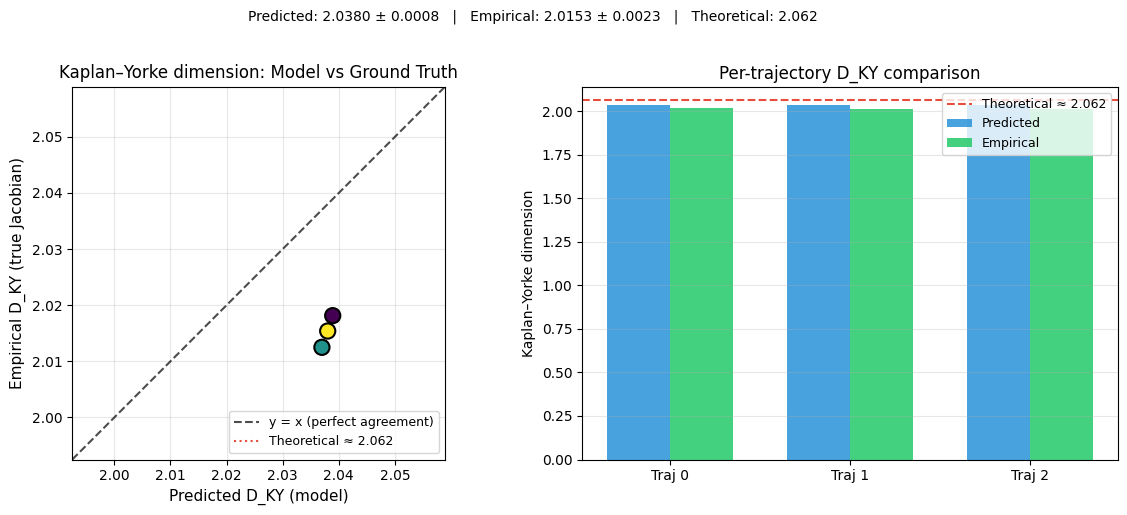

In [21]:
# Kaplan-Yorke dimension: predicted vs empirical
ky_pred = kaplan_yorke_dim(all_pred_lyap)
ky_emp = kaplan_yorke_dim(all_empirical_lyap)
ky_pred_np = np.atleast_1d(ky_pred.numpy() if torch.is_tensor(ky_pred) else np.array(ky_pred))
ky_emp_np = np.atleast_1d(ky_emp.numpy() if torch.is_tensor(ky_emp) else np.array(ky_emp))

# Theoretical KY from TRUE_LYAPUNOV (for Lorenz ~2.06)
if TRUE_LYAPUNOV is not None:
    lyap_t = np.sort(TRUE_LYAPUNOV)[::-1]
    cum = np.cumsum(lyap_t)
    k = np.where(cum > 0)[0][-1] if np.any(cum > 0) else -1
    ky_theory = (k + 1) + cum[k] / np.abs(lyap_t[k + 1]) if k >= 0 and (k + 1) < len(lyap_t) else None
else:
    ky_theory = None

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: 1:1 scatter — predicted vs empirical KY per trajectory
ax = axes[0]
ax.scatter(ky_pred_np, ky_emp_np, s=120, c=np.arange(len(ky_pred_np)), cmap='viridis', 
           edgecolors='black', linewidths=1.5, zorder=3)
lim_lo = min(ky_pred_np.min(), ky_emp_np.min()) - 0.02
lim_hi = max(ky_pred_np.max(), ky_emp_np.max()) + 0.02
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.5, label='y = x (perfect agreement)', alpha=0.7)
if ky_theory is not None:
    ax.axhline(ky_theory, color='#e74c3c', ls=':', lw=1.5, label=f'Theoretical ≈ {ky_theory:.3f}')
    ax.axvline(ky_theory, color='#e74c3c', ls=':', lw=1.5)
ax.set_xlabel('Predicted D_KY (model)', fontsize=11)
ax.set_ylabel('Empirical D_KY (true Jacobian)', fontsize=11)
ax.set_title('Kaplan–Yorke dimension: Model vs Ground Truth', fontsize=12)
ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.grid(True, alpha=0.3)

# Right: Per-trajectory comparison
ax = axes[1]
x = np.arange(len(ky_pred_np))
width = 0.35
bars1 = ax.bar(x - width/2, ky_pred_np, width, label='Predicted', color='#3498db', alpha=0.9)
bars2 = ax.bar(x + width/2, ky_emp_np, width, label='Empirical', color='#2ecc71', alpha=0.9)
if ky_theory is not None:
    ax.axhline(ky_theory, color='#e74c3c', ls='--', lw=1.5, label=f'Theoretical ≈ {ky_theory:.3f}')
ax.set_xticks(x)
ax.set_xticklabels([f'Traj {i}' for i in range(len(ky_pred_np))])
ax.set_ylabel('Kaplan–Yorke dimension')
ax.set_title('Per-trajectory D_KY comparison')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Summary text
mean_pred, std_pred = ky_pred_np.mean(), ky_pred_np.std()
mean_emp, std_emp = ky_emp_np.mean(), ky_emp_np.std()
fig.suptitle(f'Predicted: {mean_pred:.4f} ± {std_pred:.4f}   |   Empirical: {mean_emp:.4f} ± {std_emp:.4f}' + 
             (f'   |   Theoretical: {ky_theory:.3f}' if ky_theory else ''), fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

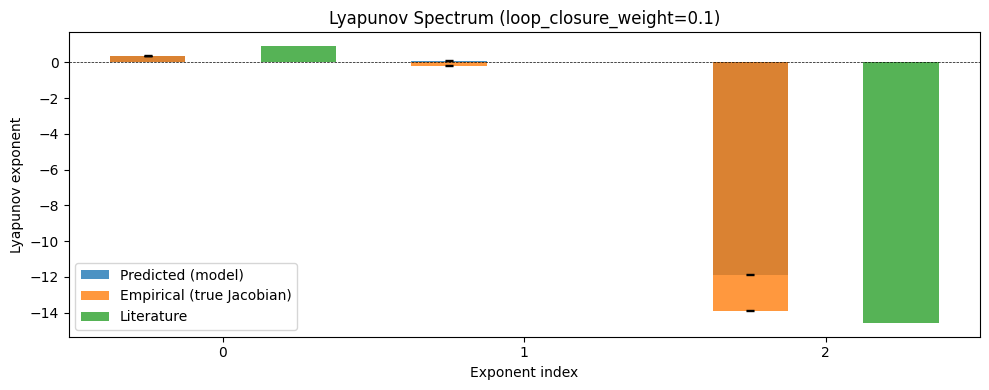

In [22]:
n_lyaps = min(10, len(pred_np))
n_lyaps = min(n_lyaps, len(emp_np))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_idx[:n_lyaps] - bar_w, pred_np[:n_lyaps], width=bar_w,
       yerr=pred_std_np[:n_lyaps], capsize=3, label="Predicted (model)", alpha=0.8)
if len(emp_np) > 0:
    ax.bar(x_idx[:n_lyaps] - bar_w, emp_np[:n_lyaps], width=bar_w,
           yerr=emp_std_np[:n_lyaps], capsize=3, label="Empirical (true Jacobian)", alpha=0.8)
if TRUE_LYAPUNOV:
    ax.bar(x_idx[:n_lyaps] + bar_w, TRUE_LYAPUNOV[:n_lyaps], width=bar_w,
           label="Literature", alpha=0.8)
ax.axhline(y=0, color='k', linestyle='--', lw=0.5)
ax.set_xticks(x_idx[:n_lyaps])
ax.set_xlabel("Exponent index"); ax.set_ylabel("Lyapunov exponent")
ax.set_title(f"Lyapunov Spectrum (loop_closure_weight={best_lambda})")
ax.legend()
plt.tight_layout(); plt.show()

Mean Kaplan–Yorke dim — Latents: 2.038  |  True state (Train): 2.015


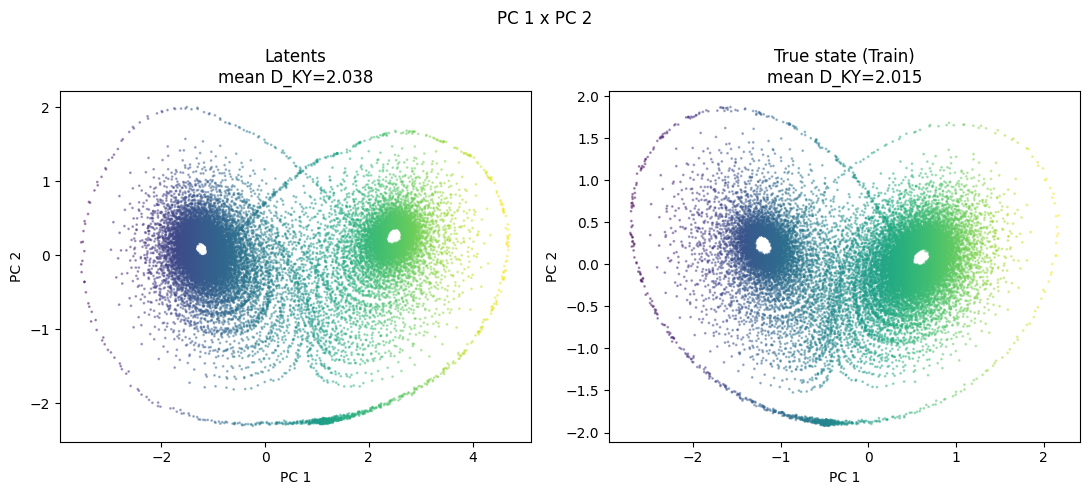

In [23]:
# Compute mean Kaplan–Yorke dimensions for latents and true state
mean_ky_latent = ky_pred_np.mean()
mean_ky_true = ky_emp_np.mean()
print(f"Mean Kaplan–Yorke dim — Latents: {mean_ky_latent:.3f}  |  True state ({label_prefix}): {mean_ky_true:.3f}")

pca_latent = PCA(n_components=2).fit(Z_flat)
pca_true = PCA(n_components=2).fit(X_true_flat)
Z_pc = pca_latent.transform(Z_flat)
X_true_pc = pca_true.transform(X_true_flat)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(Z_pc[:, 0], Z_pc[:, 1], s=1, alpha=0.4, c=Z_pc[:, 0], cmap="viridis")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[0].set_title(f"Latents\nmean D_KY={mean_ky_latent:.3f}")
axes[1].scatter(X_true_pc[:, 0], X_true_pc[:, 1], s=1, alpha=0.4, c=X_true_pc[:, 0], cmap="viridis")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
axes[1].set_title(f"True state ({label_prefix})\nmean D_KY={mean_ky_true:.3f}")
fig.suptitle("PC 1 x PC 2", fontsize=12)
plt.tight_layout(); plt.show()

## 11. Generated Predictions (Latent & Observation Space)

Roll out the model (no teacher forcing) and compare latent + observation predictions to ground truth.

Batch nMSE: 0.312875


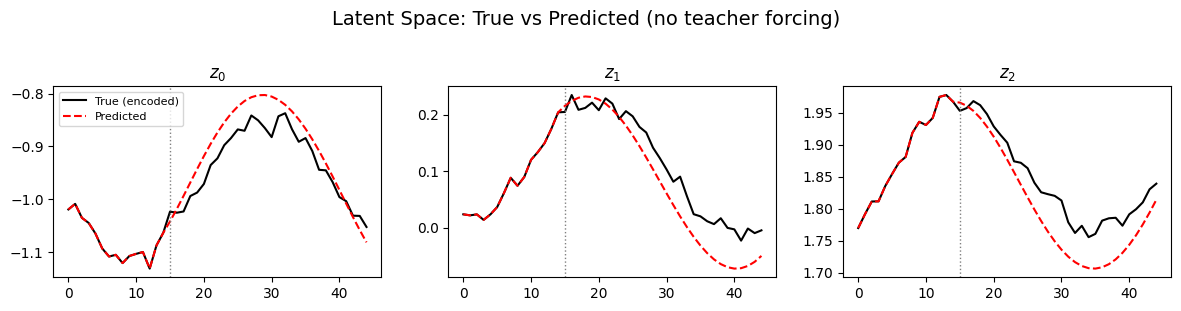

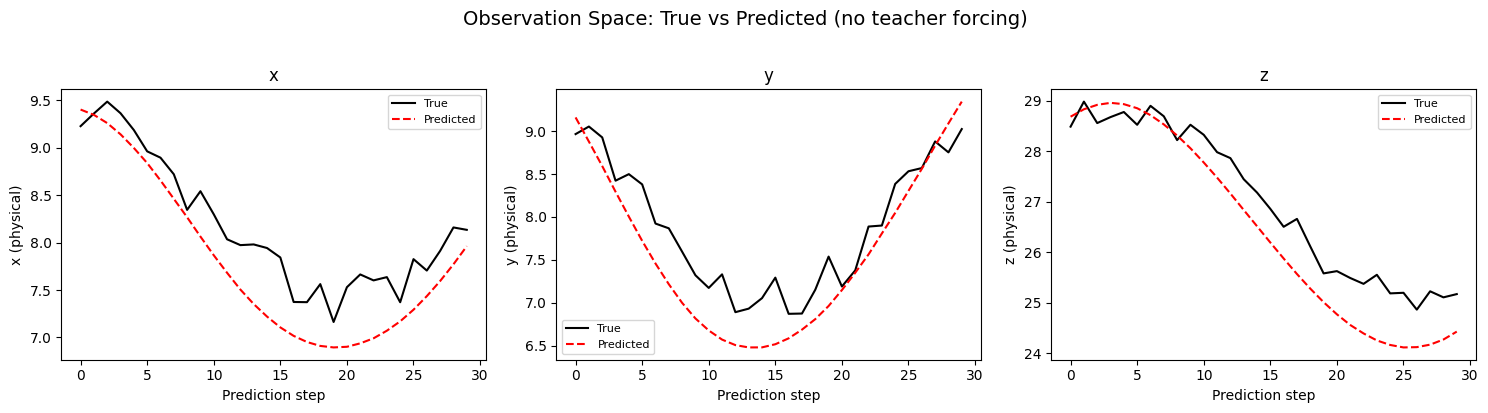

In [24]:
n_test = test_dl.dataset.sequence.shape[0]
win_idx = np.random.randint(0, n_test)
traj_obs = torch.as_tensor(test_dl.dataset.sequence[win_idx:win_idx+1]).float().to(device)

with torch.no_grad():
    result_dict = lit_model.trajectory_model_step(
        traj_obs, alpha_teacher_forcing=0.0, obs_noise_scale=0, return_decoded=True,
    )

z_pred_full = result_dict['outputs']
decoded_pred = result_dict['decoded']
obs_targets = result_dict['targets']
batch_nmse = nmse_fn(obs_targets, decoded_pred).item()
print(f"Batch nMSE: {batch_nmse:.6f}")

with torch.no_grad():
    z_true_full = lit_model.encode_trajectory(traj_obs)
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + lit_model.prediction_steps

z_pred_win = z_pred_full[0].detach().cpu().numpy()
z_true_win = z_true_full[0, :jac_window_len].detach().cpu().numpy()
obs_pred_0 = decoded_pred[0].detach().cpu().numpy()
obs_true_0 = obs_targets[0].detach().cpu().numpy()

# Latent space predictions
n_latent = z_pred_win.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
t_steps = np.arange(jac_window_len)
for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps, z_true_win[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps, z_pred_win[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1)
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0: ax.legend(fontsize=8)
for i in range(n_latent, n_rows*n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)
fig.suptitle('Latent Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Observation space predictions
dim_labels = ['x', 'y', 'z']
t_pred = np.arange(obs_pred_0.shape[0])
D_obs = obs_pred_0.shape[-1]
obs_pred_phys = obs_pred_0 * sigma + mu
obs_true_phys = obs_true_0 * sigma + mu

fig, axes_p = plt.subplots(1, min(D_obs, 3), figsize=(5*min(D_obs,3), 4), squeeze=False)
for d in range(min(D_obs, 3)):
    ax = axes_p[0, d]
    label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
    ax.plot(t_pred, obs_true_phys[:, d], 'k-', lw=1.5, label='True')
    ax.plot(t_pred, obs_pred_phys[:, d], 'r--', lw=1.5, label='Predicted')
    ax.set_xlabel('Prediction step'); ax.set_ylabel(f'{label} (physical)')
    ax.set_title(label); ax.legend(fontsize=8)
fig.suptitle('Observation Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

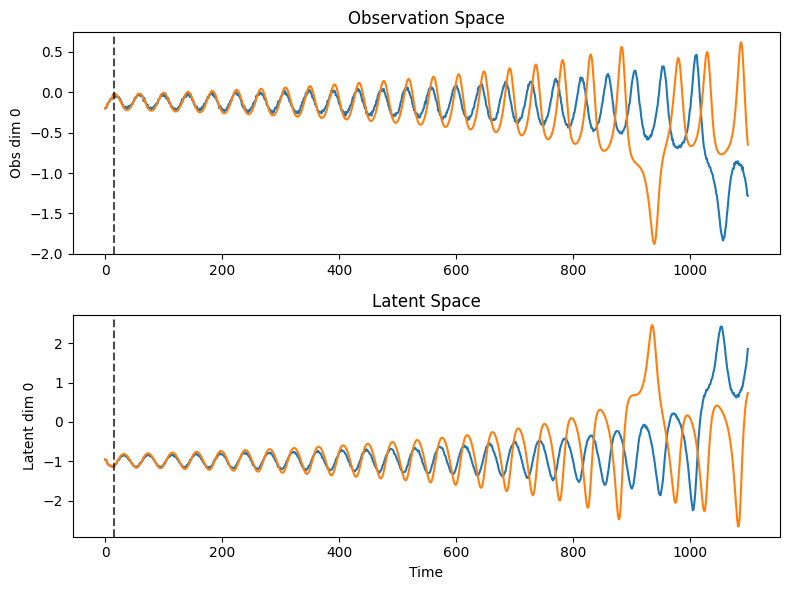

In [25]:
if hasattr(eq, 'model'):
    traj_long = trajs['test_trajs'].sequence[[0]].to(device)
else:
    traj_long = trajs['test_trajs'].sequence[[0]].to(device)[:, 100:]
with torch.no_grad():
    rd_long = lit_model.trajectory_model_step(
        traj_long, alpha_teacher_forcing=0.0, obs_noise_scale=0, return_decoded=True, strided=False,
    )
    encoded = lit_model.encode_trajectory(traj_long)
    recon = lit_model.decode_trajectory(encoded)
    # outputs is in z_dyn space; pad back to full dim for coupling decoders
    z_pred_full = lit_model._pad_to_full_dim(rd_long['outputs'])
    decoded_v2 = lit_model.decode_trajectory(z_pred_full)

fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(traj_long[0, :, 0].cpu(), label="True Observation")
axs[0].plot(decoded_v2[0, :, 0].cpu(), label="Predicted Observation")
axs[0].axvline(15, color='k', linestyle='--', alpha=0.7, label="Prediction Start")
axs[0].set_title("Observation Space"); axs[0].set_ylabel("Obs dim 0")
axs[1].plot(get_z_dyn(encoded)[0, :, 0].cpu(), label="Encoded Latent")
axs[1].plot(rd_long['outputs'][0, :, 0].cpu(), label="Predicted Latent")
axs[1].axvline(15, color='k', linestyle='--', alpha=0.7, label="Prediction Start")
axs[1].set_title("Latent Space"); axs[1].set_ylabel("Latent dim 0"); axs[1].set_xlabel("Time")
plt.tight_layout(); plt.show()

## 12. Prediction Diagnostics — Per-Window nMSE & One-Step vs Free-Running

Compute per-window normalized MSE across test trajectories, then compare
one-step (teacher-forced) vs free-running MASE.

In [26]:
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + lit_model.prediction_steps
stride = lit_model.jac_window_stride

N_TEST_TRAJS = min(3, trajs['test_trajs'].sequence.shape[0])

all_decoded_pred = []
all_obs_targets = []
all_z_pred = []
all_z_true_windows = []
all_per_window_nmse = []

for t_idx in range(N_TEST_TRAJS):
    traj_obs_i = torch.as_tensor(
        trajs['test_trajs'].sequence[t_idx:t_idx+1]
    ).float().to(device)
    with torch.no_grad():
        rd = lit_model.trajectory_model_step(
            traj_obs_i, alpha_teacher_forcing=0.0, obs_noise_scale=0, return_decoded=True,
        )
        z_true_i = lit_model.encode_trajectory(traj_obs_i)

    dec_pred = rd['decoded'].cpu()
    obs_tgt = rd['targets'].cpu()
    z_pred_i = rd['outputs'].cpu()

    N_win = dec_pred.shape[0]
    mean_var = obs_tgt.reshape(-1, obs_tgt.shape[-1]).var(dim=0).mean().clamp(min=1e-8)
    for w in range(N_win):
        w_mse = (dec_pred[w] - obs_tgt[w]).pow(2).mean()
        all_per_window_nmse.append((w_mse / mean_var).item())

    z_true_np = z_true_i[0].cpu()
    T_prime = z_true_np.shape[0]
    n_windows = max(1, (T_prime - jac_window_len) // stride + 1)
    for w in range(n_windows):
        start = w * stride
        if start + jac_window_len <= T_prime:
            all_z_true_windows.append(z_true_np[start:start + jac_window_len].numpy())

    all_decoded_pred.append(dec_pred.numpy())
    all_obs_targets.append(obs_tgt.numpy())
    all_z_pred.append(z_pred_i.numpy())

all_decoded_pred = np.concatenate(all_decoded_pred, axis=0)
all_obs_targets = np.concatenate(all_obs_targets, axis=0)
all_z_pred = np.concatenate(all_z_pred, axis=0)
all_z_true_windows = np.array(all_z_true_windows)
all_per_window_nmse = np.array(all_per_window_nmse)

print(f"Total windows: {len(all_per_window_nmse)}")
print(f"nMSE — min: {all_per_window_nmse.min():.6f}, median: {np.median(all_per_window_nmse):.6f}, "
      f"mean: {all_per_window_nmse.mean():.6f}, max: {all_per_window_nmse.max():.6f}")

Total windows: 693
nMSE — min: 0.001029, median: 0.003405, mean: 0.009128, max: 0.695734


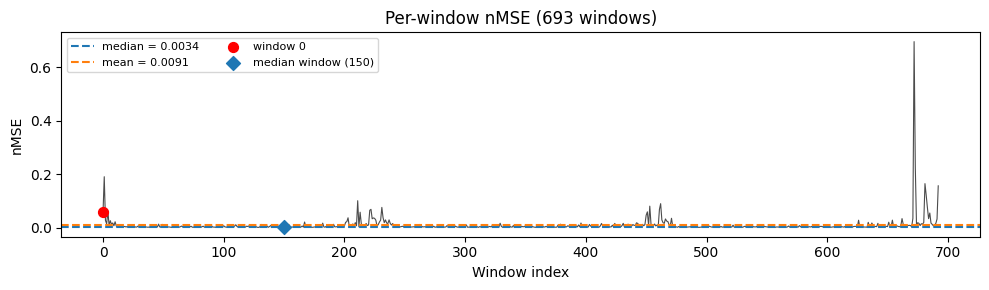

In [27]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(all_per_window_nmse, 'k-', lw=0.8, alpha=0.7)
ax.axhline(np.median(all_per_window_nmse), color='C0', ls='--', lw=1.5,
           label=f'median = {np.median(all_per_window_nmse):.4f}')
ax.axhline(all_per_window_nmse.mean(), color='C1', ls='--', lw=1.5,
           label=f'mean = {all_per_window_nmse.mean():.4f}')
median_idx = np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2]
ax.scatter([0], [all_per_window_nmse[0]], c='red', s=50, zorder=5, label=f'window 0')
ax.scatter([median_idx], [all_per_window_nmse[median_idx]], c='C0', s=50, zorder=5,
           marker='D', label=f'median window ({median_idx})')
ax.set_xlabel('Window index'); ax.set_ylabel('nMSE')
ax.set_title(f'Per-window nMSE ({len(all_per_window_nmse)} windows)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

In [28]:
# # Compare one-step vs free-running MASE (same method as diagnostics: val_dl + ratio-of-means)
# # Using mase() on test_trajs gave wrong results; diagnostics use model_mae/persistence_mae
# # from trajectory_model_step over validation batches. n_batches=100 matches compute_all_diagnostics.
# n_mase_batches = 100
# RAND_SEED = 42
# generator = torch.Generator().manual_seed(RAND_SEED)
# rand_sampler = RandomSampler(val_dl.dataset, generator=generator)
# rand_dl = DataLoader(
#     val_dl.dataset, batch_size=val_dl.batch_size, sampler=rand_sampler,
#     num_workers=val_dl.num_workers, pin_memory=getattr(val_dl, 'pin_memory', False),
# )

# model_maes_onestep = []
# model_maes_freerun = []
# persistence_maes = []

# for i, batch in enumerate(tqdm(rand_dl, desc="MASE", total=n_mase_batches)):
#     if i >= n_mase_batches:
#         break
#     batch = batch.to(device)
#     with torch.no_grad():
#         ret_onestep = lit_model.trajectory_model_step(batch, alpha_teacher_forcing=1.0)
#         ret_free = lit_model.trajectory_model_step(batch, alpha_teacher_forcing=0.0)
#     model_maes_onestep.append(ret_onestep['metric_vals']['model_mae'].item())
#     model_maes_freerun.append(ret_free['metric_vals']['model_mae'].item())
#     persistence_maes.append(ret_onestep['metric_vals']['persistence_mae'].item())

# avg_model_mae_onestep = np.mean(model_maes_onestep)
# avg_model_mae_freerun = np.mean(model_maes_freerun)
# avg_persistence = np.mean(persistence_maes)
# mase_onestep = avg_model_mae_onestep / avg_persistence
# mase_freerun = avg_model_mae_freerun / avg_persistence

# print("=" * 60)
# print("One-step vs Free-running MASE")
# print("=" * 60)
# print(f"  MASE (one-step, alpha=1): {mase_onestep:.4f}  [matches diagnostics C1]")
# print(f"  MASE (free-run, alpha=0): {mase_freerun:.4f}")

Median-loss window: index=150, nMSE=0.003405


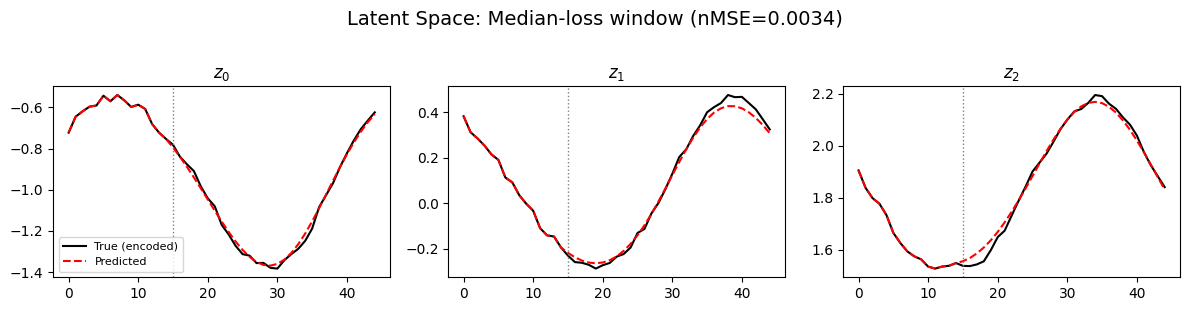

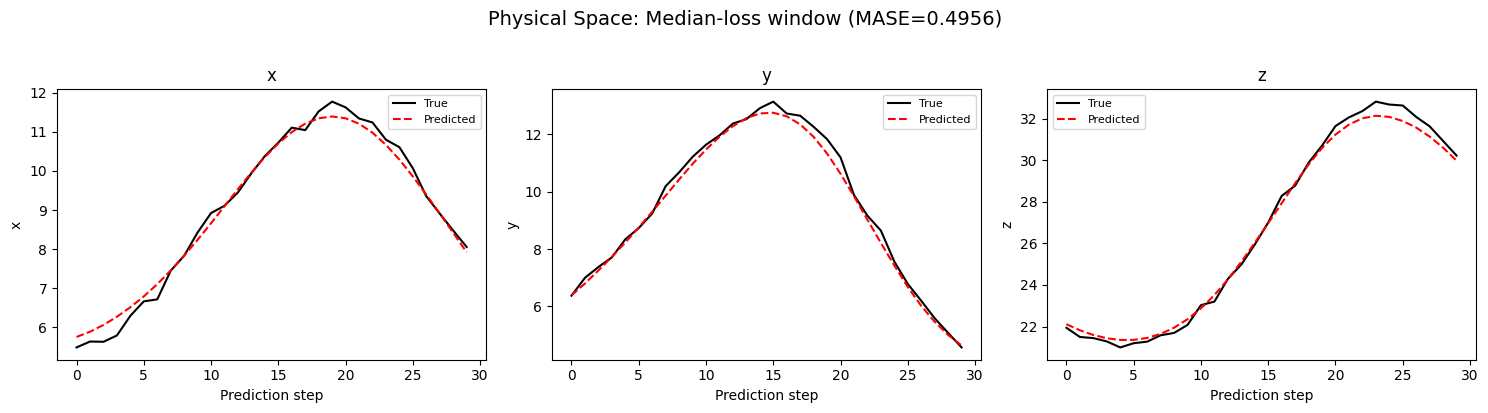

In [29]:
median_idx = int(np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2])
print(f"Median-loss window: index={median_idx}, nMSE={all_per_window_nmse[median_idx]:.6f}")

z_pred_med = all_z_pred[median_idx]
z_true_med = all_z_true_windows[median_idx]
obs_pred_med = all_decoded_pred[median_idx]
obs_true_med = all_obs_targets[median_idx]

# Latent space
n_latent = z_pred_med.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols
t_steps_med = np.arange(jac_window_len)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps_med, z_true_med[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps_med, z_pred_med[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1)
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0: ax.legend(fontsize=8)
for i in range(n_latent, n_rows*n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)
fig.suptitle(f'Latent Space: Median-loss window (nMSE={all_per_window_nmse[median_idx]:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Observation space
obs_pred_phys_med = obs_pred_med * sigma + mu
obs_true_phys_med = obs_true_med * sigma + mu
D_obs_med = obs_pred_med.shape[-1]
t_pred_med = np.arange(obs_pred_med.shape[0])
fig, axes_p = plt.subplots(1, min(D_obs_med, 3), figsize=(5*min(D_obs_med,3), 4), squeeze=False)
for d in range(min(D_obs_med, 3)):
    ax = axes_p[0, d]
    label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
    ax.plot(t_pred_med, obs_true_phys_med[:, d], 'k-', lw=1.5, label='True')
    ax.plot(t_pred_med, obs_pred_phys_med[:, d], 'r--', lw=1.5, label='Predicted')
    ax.set_xlabel('Prediction step'); ax.set_ylabel(f'{label}'); ax.set_title(label)
    ax.legend(fontsize=8)
window_mase = mase(obs_true_phys_med, obs_pred_phys_med)
fig.suptitle(f'Physical Space: Median-loss window (MASE={window_mase:.4f})', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 21. Export HTML

In [30]:
import subprocess
from datetime import datetime

now_str = datetime.now().strftime("%Y-%m-%d %H-%M-%S")
output_file = f"reports/{now_str} - {WANDB_PROJECT}_{WANDB_GROUP}_lambda_{best_lambda}"
cmd = f"uv run jupyter nbconvert --to html --output '{output_file}' '/home/eisenaj/code/JacobianODE/_jupyter/Sweep Analytics (Latent JacobianODE).ipynb'"
# Uncomment to export:
subprocess.run(cmd, shell=True)
# print(f"Export command:\n{cmd}")

[NbConvertApp] Converting notebook /home/eisenaj/code/JacobianODE/_jupyter/Sweep Analytics (Latent JacobianODE).ipynb to html
/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 1808020 bytes to /home/eisenaj/code/JacobianODE/_jupyter/reports/2026-03-25 09-58-34 - Lorenz_IND012_N2_D1_NormTrue_T3__spline_coupling__JacobianODE_sweep_from_scratch_spline_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab_lambda_0.1.html


CompletedProcess(args="uv run jupyter nbconvert --to html --output 'reports/2026-03-25 09-58-34 - Lorenz_IND012_N2_D1_NormTrue_T3__spline_coupling__JacobianODE_sweep_from_scratch_spline_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab_lambda_0.1' '/home/eisenaj/code/JacobianODE/_jupyter/Sweep Analytics (Latent JacobianODE).ipynb'", returncode=0)